# HDB Resale Prices Prediction

## Intro/abstract

HDB/govt provides the data on resale flat prices to the public, including relevant factors which influence prices such as location, flat type, remaining lease, and floor level.

This project builds
a regression model to predict resale prices, using transaction data from
data.gov.sg.

The final tuned model achieves a MAE/RMSE/some other metric of X and R2 score of Y on unseen data.

Explanation of each field provided:

## Results Summary


| Metric | Baseline RF | Tuned RF |
|--------|------------|----------|
| MAE    | 55613.33  |  51721.84  |
| RMSE   | 78708.82   |   72991.41  |
| R²     | 0.840      |  0.862    |
  
  
Errors for Test set (Baseline)  
MAE: 55613.33    
MSE: 6195078640.28  
RMSE: 78708.82  
R² Score: 0.840  

Errors for Test set (Tuned)  
MAE: 51721.84  
MSE: 584788535.94  
RMSE: 72991.41  
R² Score: 0.862  



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import time
import seaborn as sns
import sklearn
from matplotlib.ticker import EngFormatter
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OrdinalEncoder,TargetEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from joblib import dump,load


## 1. Data Loading & Cleaning
Source: [HDB Resale Flat Prices, data.gov.sg](https://data.gov.sg)  
Retrieved: October 2025

In [ ]:
df = pd.read_csv(r"/content/drive/MyDrive/Colab Notebooks/ResaleFLatPricesFromJan2017_retrieved16Oct25.csv")
pd.set_option('display.float_format', '{:.2f}'.format)
df.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.00,Improved,1979,61 years 04 months,232000.00
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.00,New Generation,1978,60 years 07 months,250000.00
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.00,New Generation,1980,62 years 05 months,262000.00
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.00,New Generation,1980,62 years 01 month,265000.00
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.00,New Generation,1980,62 years 05 months,265000.00


In [ ]:
print("Missing values: \n", df.isna().sum()) #missing data check, none in this case
print()
print(f"Duplicate rows: {df.duplicated().sum()}") # duplicates check and removal
df.drop_duplicates(inplace = True)
print(f"After removing duplicates, {df.shape[0]} rows left.")

Missing values: 
 month                  0
town                   0
flat_type              0
block                  0
street_name            0
storey_range           0
floor_area_sqm         0
flat_model             0
lease_commence_date    0
remaining_lease        0
resale_price           0
dtype: int64

Duplicate rows: 306
After removing duplicates, 217347 rows left.


## 2. Feature Engineering
Converting the following fields:  
`storey_range` (eg. 7 TO 9) → midpoint value `average_storey` (eg. 8)  
`remaining_lease` (e.g. "61 years 04 months	") → `remaining_lease_in_months` (eg. 736)    
`remaining_lease` (e.g. "61 years 04 months	") → `remaining_lease_in_years` (eg. 61.33)   
`month`: converted into datetime format

The following fields have been created:  
 `month_numeric`: sale date, measured by number of months from Jan 2017 (first data point) (Jan 2017 is labeled as 1)  
`year`: year of sale date

In [ ]:
# new fields / converting existing fields

df['month'] = pd.to_datetime(df['month'])

def duration_to_months(s):
    years = re.search(r'(\d+)\s*year', s)
    months = re.search(r'(\d+)\s*month', s)

    yr = int(years.group(1)) if years else 0
    m = int(months.group(1)) if months else 0

    return yr * 12 + m

df['remaining_lease_in_months'] = df['remaining_lease'].apply(duration_to_months)

def duration_to_years(s):
    years = re.search(r'(\d+)\s*year', s)
    months = re.search(r'(\d+)\s*month', s)

    yr = int(years.group(1)) if years else 0
    m = int(months.group(1)) if months else 0

    return (yr * 12 + m)/12
df['remaining_lease_in_years'] = df['remaining_lease'].apply(duration_to_years)

def avg_storey_range(storey_range):
    parts = storey_range.split(' TO ')
    return (int(parts[0]) + int(parts[1])) // 2
df['average_storey'] = df['storey_range'].apply(avg_storey_range)

df['month_numeric'] = (df['month'].dt.year - df['month'].dt.year.min()) * 12 + df['month'].dt.month # number of months from Jan 2017

df['year'] = df['month'].dt.year

df


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,remaining_lease_in_months,remaining_lease_in_years,average_storey,month_numeric,year
0,2017-01-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.00,Improved,1979,61 years 04 months,232000.00,736,61.33,11,1,2017
1,2017-01-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.00,New Generation,1978,60 years 07 months,250000.00,727,60.58,2,1,2017
2,2017-01-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.00,New Generation,1980,62 years 05 months,262000.00,749,62.42,2,1,2017
3,2017-01-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.00,New Generation,1980,62 years 01 month,265000.00,745,62.08,5,1,2017
4,2017-01-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.00,New Generation,1980,62 years 05 months,265000.00,749,62.42,2,1,2017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217648,2025-07-01,YISHUN,EXECUTIVE,824,YISHUN ST 81,04 TO 06,146.00,Maisonette,1987,61 years 05 months,980000.00,737,61.42,5,103,2025
217649,2025-09-01,YISHUN,EXECUTIVE,877,YISHUN ST 81,10 TO 12,145.00,Maisonette,1987,61 years 03 months,980000.00,735,61.25,11,105,2025
217650,2025-09-01,YISHUN,EXECUTIVE,834,YISHUN ST 81,04 TO 06,146.00,Maisonette,1988,61 years 04 months,990000.00,736,61.33,5,105,2025
217651,2025-05-01,YISHUN,MULTI-GENERATION,632,YISHUN ST 61,04 TO 06,147.00,Multi Generation,1987,61 years 06 months,945000.00,738,61.50,5,101,2025


## 3. Exploratory Data Analysis

### Correlation Matrix of features  
`lease_commence_date` and `remaining_lease_in_months` have 0.99 correlation  
`year` and `month_numeric` also have 0.99 correlation  
In both cases, one field is derived from the other. Only need to include one feature from each of the pairs in our model.

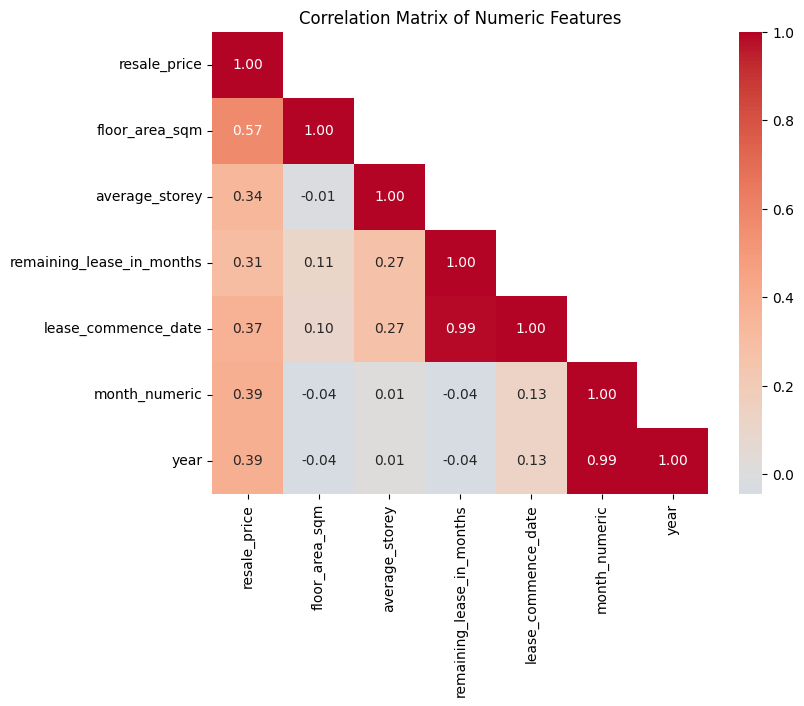

In [ ]:
numeric_cols = ['resale_price', 'floor_area_sqm', 'average_storey',
                 'remaining_lease_in_months', 'lease_commence_date', 'month_numeric', 'year']
corr_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numeric Features')
plt.show()

### Distribution of resale prices  
Prices are right skewed, with skewness at 0.95.  
This is likely due to a small number of large premium flats at prime locations sold at extremely high prices, pulling the mean above the median.

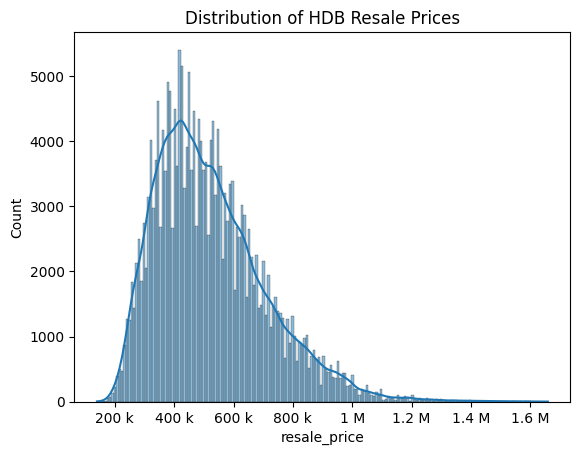

Skewness: 0.9506379464031036


In [ ]:
ax = sns.histplot(df['resale_price'], kde=True)
ax.xaxis.set_major_formatter(EngFormatter()) #format to k and M as units
plt.title("Distribution of HDB Resale Prices")
plt.show()

# Check for skewness
print("Skewness:", df['resale_price'].skew())

### Distribution of remaining flat lease on resold flats
Large number of flats sold with more than 90+ years, suggesting homeowners selling their flats after hitting the Minimum Occupancy Period (MOP).
Multiple other peaks observed, one reason might be an increase in BTO flats built in those periods, resulting in more flats with same number of remaining lease.

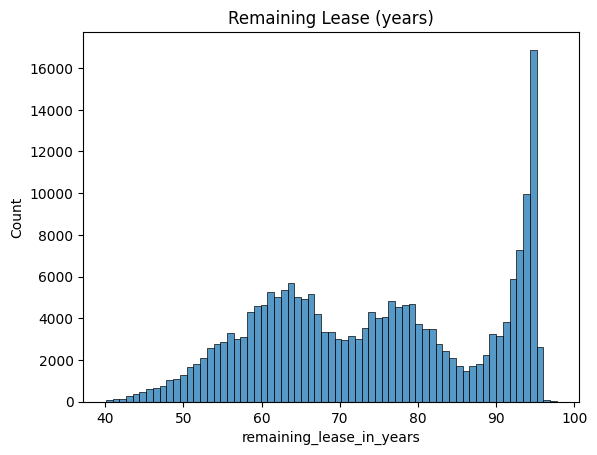

In [ ]:
ax = sns.histplot(df['remaining_lease_in_years'])
plt.title("Remaining Lease (years)")
plt.show()

### Distribution of Lease Commence Year
Large numbers of resale flats from ~1985, ~1997 and post 2015, supporting our theory in the above cell. A large number of HDB flats were built in the 1980s and 1990s period corresponding to the peaks. Just a result of higher number of flats with leases commencing in those years.

Text(0, 0.5, 'Count')

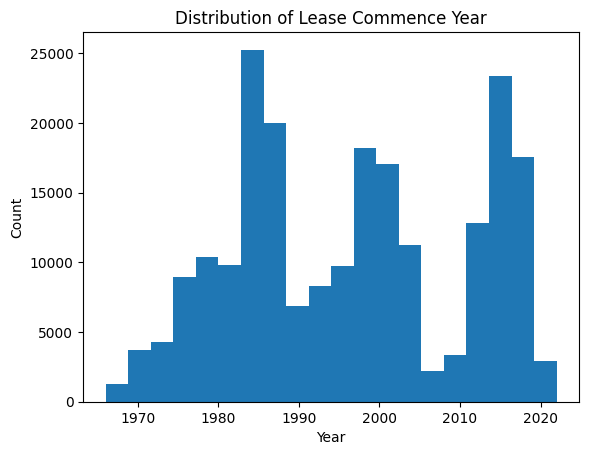

In [ ]:
ax = df['lease_commence_date'].plot(title ='Distribution of Lease Commence Year',kind='hist', bins = 20)
ax.set_xlabel('Year')
ax.set_ylabel('Count')

### Top 5 Towns by Highest Average Resale Prices and Sales Counts for each Flat Type  
Bukit Merah is a prime location, with resale prices in the top 5 across almost all Flat Types.

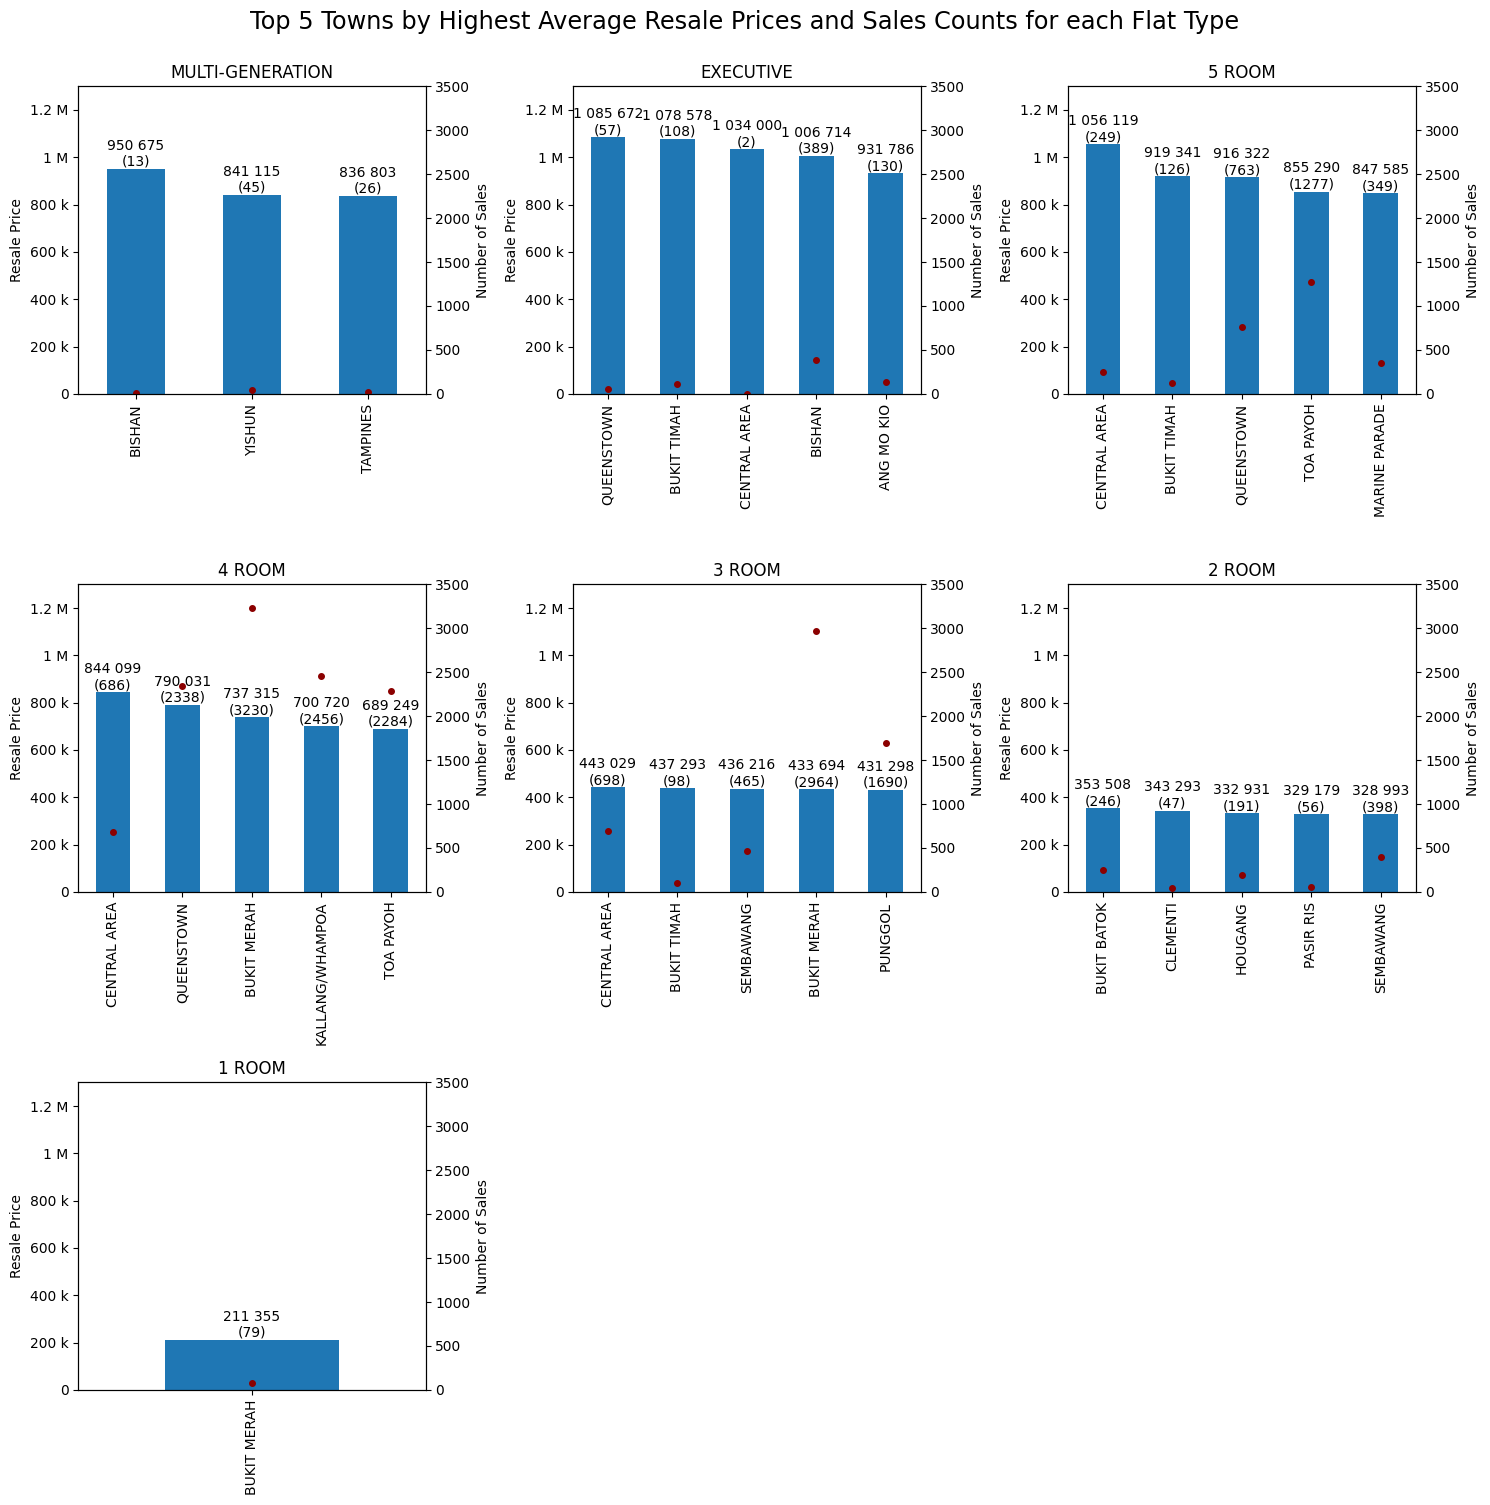

In [ ]:
sortList = df['flat_type'].unique().tolist()
sortList.sort(reverse = True)
n = len(sortList)

cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()

for index,name in enumerate(sortList):
  ax = axes[index]
  mean_prices = df[df['flat_type'] == name].groupby('town')['resale_price'].mean().sort_values(ascending = False).head() #resale price bar graph
  mean_prices.plot(kind = 'bar', title = name, ax=ax)
  ax.set_xlabel('')
  ax.set_ylabel('Resale Price')
  ax.set_ylim(0, 1300000)
  ax.yaxis.set_major_formatter(EngFormatter())

  ax2 = ax.twinx() #number of sales (dots)
  count_sales = df[df['flat_type'] == name].groupby('town')['resale_price'].count().reindex(mean_prices.index)
  ax2.plot(range(len(count_sales)), count_sales.values, color='darkred', marker='o',linestyle = '', markersize = 4)
  ax2.set_ylabel('Number of Sales')
  #ax2.tick_params(axis='y', labelcolor='darkred')
  ax2.set_ylim(0, 3500)

  for p,count in zip(ax.patches,count_sales): #add label on each bar
    value = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2, value,  f'{value:,.0f}'.replace(',', ' ')+f'\n({count})', ha='center', va='bottom',)


for i in range(index+1,len(axes)):
  fig.delaxes(axes[i])

fig.suptitle('Top 5 Towns by Highest Average Resale Prices and Sales Counts for each Flat Type', fontsize = 'xx-large', y=1)
plt.tight_layout()
plt.show()

## 4. Model Training  
**Features used:** `town`, `flat_type`, `average_storey`, `floor_area_sqm`, `flat_model`, `lease_commence_date`, `remaining_lease_in_months`, `month_numeric`, `year`

**Train/test split:** Train on data before 2024, test on data after 2025, avoiding data leakage

**Encoding:** Target encoding for categorical features (`town`, `flat_type`,
`flat_model`)

In [ ]:
#pick features to regress on
features = ['town','flat_type','average_storey','floor_area_sqm','flat_model','lease_commence_date','remaining_lease_in_months','month_numeric','year']

In [ ]:
#train test split by date

df = df.sort_values('month').reset_index(drop=True) #sorts dataframe by date col, then resets the index

split_idx = int(len(df) * 0.8)
cutoff_Month = df.loc[split_idx, 'month'] # 80% split monthwise
train_df = df[df['month'] < cutoff_Month]
test_df  = df[df['month'] >= cutoff_Month]

print(f"Train: {train_df['month'].min().date()} → {train_df['month'].max().date()}  ({len(train_df):,} rows)")
print(f"Test:  {test_df['month'].min().date()} → {test_df['month'].max().date()}  ({len(test_df):,} rows)")
print(f"Cutoff date: {cutoff_Month.date()}")

Train: 2017-01-01 → 2024-02-01  (173,611 rows)
Test:  2024-03-01 → 2025-10-01  (43,736 rows)
Cutoff date: 2024-03-01


In [ ]:
X_train = train_df[features]
y_train = train_df['resale_price']

X_test = test_df[features]
y_test = test_df['resale_price']

In [ ]:
categorical_features = X_train.select_dtypes(include='object').columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('target_enc', TargetEncoder(target_type='continuous'), categorical_features)
    ],
    remainder='passthrough'
)

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=67))
])

In [ ]:
print("Start training:", time.strftime('%H:%M:%S', time.gmtime()))
model_pipeline.fit(X_train, y_train)
print("End training:", time.strftime('%H:%M:%S', time.gmtime()))

X_train_encoded = model_pipeline.named_steps['preprocessor'].transform(X_train)
X_test_encoded = model_pipeline.named_steps['preprocessor'].transform(X_test)


Start training: 14:38:10
End training: 14:40:09


In [ ]:
# use model to predict test and train sets
y_pred_xtest = model_pipeline.predict(X_test) #test set

maeTest = mean_absolute_error(y_test, y_pred_xtest)
mseTest = mean_squared_error(y_test, y_pred_xtest)
rmseTest = np.sqrt(mseTest)
r2Test = r2_score(y_test, y_pred_xtest)

print('\nErrors for Test set')
print(f"MAE: {maeTest:.2f}")
print(f"MSE: {mseTest:.2f}")
print(f"RMSE: {rmseTest:.2f}")
print(f"R² Score: {r2Test:.3f}")

y_pred_xtrain = model_pipeline.predict(X_train) #train set

maeTrain = mean_absolute_error(y_train, y_pred_xtrain)
mseTrain = mean_squared_error(y_train, y_pred_xtrain)
rmseTrain = np.sqrt(mseTrain)
r2Train = r2_score(y_train, y_pred_xtrain)

print('\nErrors for Train set')
print(f"MAE: {maeTrain:.2f}")
print(f"MSE: {mseTrain:.2f}")
print(f"RMSE: {rmseTrain:.2f}")
print(f"R² Score: {r2Train:.3f}")


Errors for Test set
MAE: 52813.05
MSE: 5596965082.30
RMSE: 74812.87
R² Score: 0.855

Errors for Train set
MAE: 16814.61
MSE: 826727963.62
RMSE: 28752.88
R² Score: 0.972


## 5. Model Iteration and Diagnostics
Modeling decisions and iterations done before settling on the final feature set and preprocessing encoder.

### Choice of encoder:  
OrdinalEncoder was originally used to convert categorical features such as `town`, `flat_type`, `flat_model` etc. However, since OrdinalEncoder assigns arbiraru integer labels to each category, it implies a hierachy (eg. town 8 is bigger than town 2) which may mislead the model.  
Target Encoding was then tested, which converts categorical features to the average `resale_price` as computed from the training set. This method utilises useful price information instead of arbitrary values.  
The result from switching encoders produced a train R2 value of 0.94 but test R2 value was significantly lower at 0.58, indicating a different issue unrelated to encode choice.

### Diagnosis of test R2 value drop  
Checks were conducted on the monthly mean resale price to determine if price drift was the issue.
`print(train_df.groupby(train_df['month'].dt.year)['resale_price'].mean())`  

Average resale prices  
2017   443743.44  
2018   441310.44  
2019   432180.07  
2020   452312.74  
2021   511417.39  
2022   549701.07  
2023   571814.76  
2024   612597.98  
2025   652029.42  

Results show that resale prices have been increasing, with about a 47% increase in average price from 2017 to 2025.

To fix this issue, a `month_numeric` feature was added to allow the model to learn about the price drift over time  
`df['month_numeric'] = (df['month'].dt.year - df['month'].dt.year.min()) * 12 + df['month'].dt.month`  
After adding this feature, test R2 score improved to 0.83, confirming that the issue was indeed due to price drift.  

A separate `year` feature was also tested.
`df['year'] = df['month'].dt.year`  
The idea behind it was to capture effects of new policies/yearly trends which may not be obvious from `month_numeric` feature.  
This improved test R2 score to 0.848.

Thus even though both features have a correlation of 0.99 (as shown in the EDA section), both features were added and kept in the feature list.

Similarly, `lease_commence_date` and `remaining_lease_in_months` reflect nearly the same information and have 0.99 correlation, but including both improved test R2 values from 0.848 (without `lease_commence_date`) to 0.859 (including both)


Therefore our final feature set is  
features_final = `town`, `flat_type`, `average_storey`, `floor_area_sqm`, `flat_model`, `lease_commence_date`, `remaining_lease_in_months`, `month_numeric`, `year`

## 6. Hyperparameter Tuning  
Random search is used for hyperparameter tuning

In [ ]:
param_distributions = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [8, 10, 15, 20, 25, None],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', 0.5, 0.8, 1 ]
}

random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=67),
    param_distributions=param_distributions,
    n_iter=30,
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=67,
    verbose=2,
    n_jobs=2
)

random_search.fit(X_train_encoded, y_train)
print("Best Parameters:", random_search.best_params_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best Parameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': None}


In [ ]:
model_pipeline_tuned = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=300, min_samples_split=2, min_samples_leaf=1, max_features=0.5, max_depth=None, random_state=67))
])
model_pipeline_tuned.fit(X_train,y_train)

y_pred_xtest_tuned = model_pipeline_tuned.predict(X_test)
maeTestV2 = mean_absolute_error(y_test, y_pred_xtest_tuned)
mseTestV2 = mean_squared_error(y_test, y_pred_xtest_tuned)
rmseTestV2 = np.sqrt(mseTestV2)
r2TestV2 = r2_score(y_test, y_pred_xtest_tuned)

print('\nErrors for Test set')
print(f"MAE: {maeTestV2:.2f}")
print(f"MSE: {mseTestV2:.2f}")
print(f"RMSE: {rmseTestV2:.2f}")
print(f"R² Score: {r2TestV2:.3f}")

y_pred_xtrain_tuned = model_pipeline_tuned.predict(X_train)
maeTrainV2 = mean_absolute_error(y_train, y_pred_xtrain_tuned)
mseTrainV2 = mean_squared_error(y_train, y_pred_xtrain_tuned)
rmseTrainV2 = np.sqrt(mseTrainV2)
r2TrainV2 = r2_score(y_train, y_pred_xtrain_tuned)
print('\nErrors for Train set')
print(f"MAE: {maeTrainV2:.2f}")
print(f"MSE: {mseTrainV2:.2f}")
print(f"RMSE: {rmseTrainV2:.2f}")
print(f"R² Score: {r2TrainV2:.3f}")


Errors for Test set
MAE: 51721.84
MSE: 5327745754.30
RMSE: 72991.41
R² Score: 0.862

Errors for Train set
MAE: 16286.17
MSE: 584788535.94
RMSE: 24182.40
R² Score: 0.980


In [ ]:
#saving tuned model
model_path = '/content/drive/MyDrive/Colab Notebooks/final_model.pkl'
dump(model_pipeline_tuned, model_path)

['/content/drive/MyDrive/Colab Notebooks/final_model.pkl']

## 7. Evaluation  
After tuning the optimal parameters are `n_estimators`: 300, `min_samples_split`: 2, `min_samples_leaf`: 1, `max_features`: 0.5, `max_depth`: None  
Test R2 score improved to 0.862, while  
Train R2 score improved to 0.980.

In [ ]:
#load saved model
model_path = '/content/drive/MyDrive/Colab Notebooks/final_model.pkl'
loaded_pipeline = load(model_path)

In [ ]:
y_pred_test = loaded_pipeline.predict(X_test)
y_pred_train = loaded_pipeline.predict(X_train)

In [ ]:
maeTestV2 = mean_absolute_error(y_test, y_pred_test)
mseTestV2 = mean_squared_error(y_test, y_pred_test)
rmseTestV2 = np.sqrt(mseTestV2)
r2TestV2 = r2_score(y_test, y_pred_test)

print('\nErrors for Test set')
print(f"MAE: {maeTestV2:.2f}")
print(f"MSE: {mseTestV2:.2f}")
print(f"RMSE: {rmseTestV2:.2f}")
print(f"R² Score: {r2TestV2:.3f}")

maeTrainV2 = mean_absolute_error(y_train, y_pred_train)
mseTrainV2 = mean_squared_error(y_train, y_pred_train)
rmseTrainV2 = np.sqrt(mseTrainV2)
r2TrainV2 = r2_score(y_train, y_pred_train)
print('\nErrors for Train set')
print(f"MAE: {maeTrainV2:.2f}")
print(f"MSE: {mseTrainV2:.2f}")
print(f"RMSE: {rmseTrainV2:.2f}")
print(f"R² Score: {r2TrainV2:.3f}")


Errors for Test set
MAE: 51721.84
MSE: 5327745754.30
RMSE: 72991.41
R² Score: 0.862

Errors for Train set
MAE: 16286.17
MSE: 584788535.94
RMSE: 24182.40
R² Score: 0.980


## 8. Feature Importance  
`flat_model` is the strongest predictor, followed by `town`. Both `average_storey` and `month_numeric` tie for third place

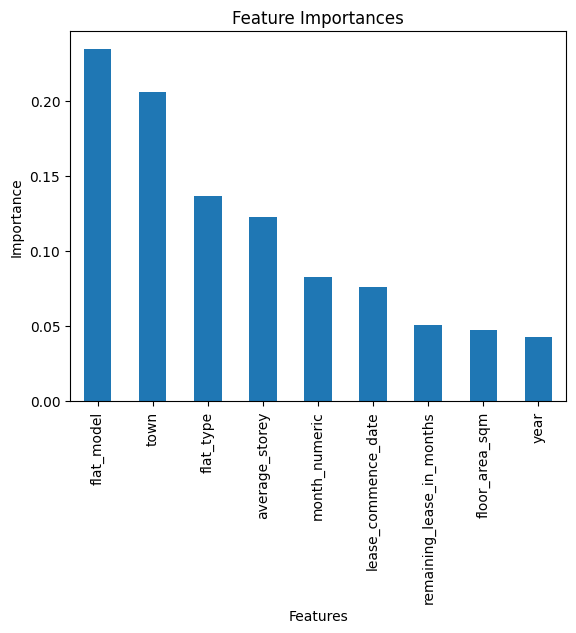

In [ ]:
# Plot feature importances
featureImpt = loaded_pipeline.named_steps['regressor'].feature_importances_

importances = pd.Series(featureImpt, index=X_train.columns).sort_values(ascending = False) # convert to df, sort in ascending order

plot = importances.plot(kind='bar')
plot.set(title='Feature Importances', xlabel='Features', ylabel='Importance')
plt.show()


## 9. Future Improvements
The project could still be improved further by implementing the following (work in progress):
1) utilise log price and compare with normal price (to add under model iteraiton and improvements, after checking which is better)
2) add validation set so we are not optimising to the test set
3) add more features such as proximity to mrt etc